
# 08 — Behavior and Customer Prediction

**Product Pulse**

This notebook trains two separate classification systems using the final datasets produced by Notebook 07.

---

## Problem A — Retailrocket

**Goal:** Predict whether an active visitor will make a transaction during the next **7 days** from behavior observed during the previous **21 days**.

Retailrocket is an **extreme rare-event classification problem**, so:

- class weighting is used during training,
- accuracy is not used as a headline metric,
- PR-AUC, lift, precision@K, and recall@K are emphasized,
- validation and test sets are never rebalanced,
- model outputs are called **propensity scores**, not calibrated probabilities.

---

## Problem B — Online Retail II

**Goal:** Predict whether an existing customer will purchase again during the next **60 days** from the previous **180 days** of purchase history.

Online Retail is **not strongly imbalanced**, so:

- no class balancing is applied,
- Logistic Regression uses StandardScaler,
- HistGradientBoosting is trained on the original feature scales.

---

For each problem:

1. Load chronological train / validation / test splits.
2. Train Logistic Regression and HistGradientBoosting.
3. Select the model using validation PR-AUC.
4. Select a threshold using validation F1.
5. Evaluate once on the untouched test set.
6. Report ranking metrics and lift.
7. Save compact results and model artifacts.


In [1]:

from pathlib import Path
import warnings

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    average_precision_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_sample_weight

warnings.filterwarnings("ignore", category=FutureWarning)

PROJECT_ROOT = Path.home() / "Desktop" / "resume_projects" / "ProductPulse"

MODEL_DATA_DIR = (
    PROJECT_ROOT
    / "data"
    / "processed"
    / "07_modeling"
)

RR_DIR = MODEL_DATA_DIR / "retailrocket"
OR_DIR = MODEL_DATA_DIR / "online_retail"

ARTIFACTS_DIR = (
    PROJECT_ROOT
    / "artifacts"
    / "models"
)

ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Model data:", MODEL_DATA_DIR)
print("Artifacts :", ARTIFACTS_DIR)


Model data: /Users/noopur/Desktop/resume_projects/ProductPulse/data/processed/07_modeling
Artifacts : /Users/noopur/Desktop/resume_projects/ProductPulse/artifacts/models


## 1. Shared helper functions

In [2]:

def load_split_dataset(folder):
    paths = {
        "train": folder / "train.parquet",
        "validation": folder / "validation.parquet",
        "test": folder / "test.parquet",
    }

    for split_name, path in paths.items():
        if not path.exists():
            raise FileNotFoundError(
                f"{path} not found. Run Notebook 07 first."
            )

    return {
        split_name: pd.read_parquet(path)
        for split_name, path in paths.items()
    }


def numeric_matrix(df, feature_cols):
    return (
        df[feature_cols]
        .replace([np.inf, -np.inf], np.nan)
    )


def best_f1_threshold(y_true, score):
    precision, recall, thresholds = precision_recall_curve(
        y_true,
        score,
    )

    if len(thresholds) == 0:
        return 0.5

    f1_values = (
        2
        * precision[:-1]
        * recall[:-1]
        / (
            precision[:-1]
            + recall[:-1]
            + 1e-12
        )
    )

    best_idx = int(np.nanargmax(f1_values))
    return float(thresholds[best_idx])


def precision_at_fraction(y_true, score, fraction):
    y_true = np.asarray(y_true)
    score = np.asarray(score)

    n = max(
        1,
        int(np.ceil(len(score) * fraction)),
    )

    idx = np.argsort(score)[::-1][:n]

    return float(y_true[idx].mean())


def recall_at_fraction(y_true, score, fraction):
    y_true = np.asarray(y_true)
    score = np.asarray(score)

    total_positives = y_true.sum()

    if total_positives == 0:
        return np.nan

    n = max(
        1,
        int(np.ceil(len(score) * fraction)),
    )

    idx = np.argsort(score)[::-1][:n]

    return float(
        y_true[idx].sum()
        / total_positives
    )


def lift_at_fraction(y_true, score, fraction):
    base_rate = float(np.mean(y_true))

    if base_rate == 0:
        return np.nan

    top_precision = precision_at_fraction(
        y_true,
        score,
        fraction,
    )

    return float(
        top_precision
        / base_rate
    )


def ranking_metrics(y_true, score):
    return {
        "precision_at_1pct": precision_at_fraction(
            y_true, score, 0.01
        ),
        "recall_at_1pct": recall_at_fraction(
            y_true, score, 0.01
        ),
        "lift_at_1pct": lift_at_fraction(
            y_true, score, 0.01
        ),
        "precision_at_5pct": precision_at_fraction(
            y_true, score, 0.05
        ),
        "recall_at_5pct": recall_at_fraction(
            y_true, score, 0.05
        ),
        "lift_at_5pct": lift_at_fraction(
            y_true, score, 0.05
        ),
        "precision_at_10pct": precision_at_fraction(
            y_true, score, 0.10
        ),
        "recall_at_10pct": recall_at_fraction(
            y_true, score, 0.10
        ),
        "lift_at_10pct": lift_at_fraction(
            y_true, score, 0.10
        ),
    }


def evaluate_scores(
    y_true,
    score,
    threshold,
    model_name,
    split_name,
):
    pred = (
        score >= threshold
    ).astype(int)

    result = {
        "model": model_name,
        "split": split_name,
        "roc_auc": roc_auc_score(
            y_true,
            score,
        ),
        "pr_auc": average_precision_score(
            y_true,
            score,
        ),
        "f1": f1_score(
            y_true,
            pred,
            zero_division=0,
        ),
        "brier_score": brier_score_loss(
            y_true,
            score,
        ),
        "threshold": threshold,
        "positive_rate": float(
            np.mean(y_true)
        ),
    }

    result.update(
        ranking_metrics(
            y_true,
            score,
        )
    )

    return result


def make_logistic_model(
    balanced=False,
):
    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "scaler",
            StandardScaler(),
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1500,
                class_weight=(
                    "balanced"
                    if balanced
                    else None
                ),
                random_state=42,
            ),
        ),
    ])


def make_histgb_model():
    return Pipeline([
        (
            "imputer",
            SimpleImputer(
                strategy="median",
            ),
        ),
        (
            "model",
            HistGradientBoostingClassifier(
                learning_rate=0.08,
                max_iter=180,
                max_leaf_nodes=31,
                l2_regularization=1.0,
                random_state=42,
            ),
        ),
    ])


def plot_precision_recall(
    y_true,
    score_dict,
    title,
):
    fig, ax = plt.subplots(
        figsize=(8, 5)
    )

    for model_name, score in score_dict.items():
        precision, recall, _ = precision_recall_curve(
            y_true,
            score,
        )

        ap = average_precision_score(
            y_true,
            score,
        )

        ax.plot(
            recall,
            precision,
            label=f"{model_name} (AP={ap:.4f})",
        )

    baseline = float(
        np.mean(y_true)
    )

    ax.axhline(
        baseline,
        linestyle="--",
        label=f"Positive-rate baseline ({baseline:.4f})",
    )

    ax.set_title(title)
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.legend()

    fig.tight_layout()

    return fig



# 2. Retailrocket — 7-day transaction propensity

Retailrocket is highly imbalanced.  
Class weighting is therefore applied **only during training**.

Validation and test data retain their original real-world class distribution.


In [3]:

rr = load_split_dataset(
    RR_DIR
)

rr_train = rr["train"]
rr_val = rr["validation"]
rr_test = rr["test"]

rr_split_summary = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test",
    ],
    "rows": [
        len(rr_train),
        len(rr_val),
        len(rr_test),
    ],
    "unique_visitors": [
        rr_train["visitorid"].nunique(),
        rr_val["visitorid"].nunique(),
        rr_test["visitorid"].nunique(),
    ],
    "positive_rate_pct": [
        100 * rr_train[
            "target_future_transaction"
        ].mean(),
        100 * rr_val[
            "target_future_transaction"
        ].mean(),
        100 * rr_test[
            "target_future_transaction"
        ].mean(),
    ],
})

display(rr_split_summary)


,split,rows,unique_visitors,positive_rate_pct
0,train,1807583,723889,0.048186
1,validation,776394,417286,0.039928
2,test,637924,349875,0.043265


In [4]:

RR_FEATURES = [
    "events_21d",
    "unique_items_21d",
    "views_21d",
    "carts_21d",
    "transactions_21d",
    "views_7d",
    "carts_7d",
    "transactions_7d",
    "recency_hours",
    "active_span_days_21d",
    "cart_per_view_21d",
    "transaction_per_view_21d",
]

RR_TARGET = "target_future_transaction"

X_rr_train = numeric_matrix(
    rr_train,
    RR_FEATURES,
)
y_rr_train = rr_train[
    RR_TARGET
].to_numpy()

X_rr_val = numeric_matrix(
    rr_val,
    RR_FEATURES,
)
y_rr_val = rr_val[
    RR_TARGET
].to_numpy()

X_rr_test = numeric_matrix(
    rr_test,
    RR_FEATURES,
)
y_rr_test = rr_test[
    RR_TARGET
].to_numpy()

print("Feature count:", len(RR_FEATURES))
print("Training rows:", len(X_rr_train))
print("Training positives:", int(y_rr_train.sum()))
print(
    "Training positive rate:",
    f"{100 * y_rr_train.mean():.6f}%"
)


Feature count: 12
Training rows: 1807583
Training positives: 871
Training positive rate: 0.048186%


In [5]:

rr_logistic = make_logistic_model(
    balanced=True,
)

rr_histgb = make_histgb_model()

rr_logistic.fit(
    X_rr_train,
    y_rr_train,
)

rr_histgb_weights = compute_sample_weight(
    class_weight="balanced",
    y=y_rr_train,
)

rr_histgb.fit(
    X_rr_train,
    y_rr_train,
    model__sample_weight=rr_histgb_weights,
)

print("Retailrocket models trained with class balancing.")


Retailrocket models trained with class balancing.


In [6]:

rr_val_score_lr = (
    rr_logistic.predict_proba(
        X_rr_val
    )[:, 1]
)

rr_val_score_hgb = (
    rr_histgb.predict_proba(
        X_rr_val
    )[:, 1]
)

rr_threshold_lr = best_f1_threshold(
    y_rr_val,
    rr_val_score_lr,
)

rr_threshold_hgb = best_f1_threshold(
    y_rr_val,
    rr_val_score_hgb,
)

rr_validation_metrics = pd.DataFrame([
    evaluate_scores(
        y_rr_val,
        rr_val_score_lr,
        rr_threshold_lr,
        "LogisticRegression",
        "validation",
    ),
    evaluate_scores(
        y_rr_val,
        rr_val_score_hgb,
        rr_threshold_hgb,
        "HistGradientBoosting",
        "validation",
    ),
])

display(rr_validation_metrics)


,model,split,roc_auc,pr_auc,f1,brier_score,threshold,positive_rate,precision_at_1pct,recall_at_1pct,lift_at_1pct,precision_at_5pct,recall_at_5pct,lift_at_5pct,precision_at_10pct,recall_at_10pct,lift_at_10pct
0,LogisticRegression,validation,0.865926,0.049681,0.143519,0.110907,1.000000,0.000399,0.014426,0.36129,36.128753,0.004946,0.619355,12.387001,0.002795,0.700000,6.999946
1,HistGradientBoosting,validation,0.859549,0.064584,0.169903,0.081976,0.980445,0.000399,0.015971,0.40000,39.999691,0.004869,0.609677,12.193454,0.002679,0.670968,6.709626


In [7]:

rr_selected_name = (
    rr_validation_metrics
    .sort_values(
        "pr_auc",
        ascending=False,
    )
    .iloc[0]["model"]
)

if rr_selected_name == "HistGradientBoosting":
    rr_selected_model = rr_histgb
    rr_selected_threshold = rr_threshold_hgb
else:
    rr_selected_model = rr_logistic
    rr_selected_threshold = rr_threshold_lr

print(
    "Selected Retailrocket model:",
    rr_selected_name,
)
print(
    "Validation-selected threshold:",
    round(rr_selected_threshold, 6),
)


Selected Retailrocket model: HistGradientBoosting
Validation-selected threshold: 0.980445


In [8]:

rr_test_score_lr = (
    rr_logistic.predict_proba(
        X_rr_test
    )[:, 1]
)

rr_test_score_hgb = (
    rr_histgb.predict_proba(
        X_rr_test
    )[:, 1]
)

rr_test_metrics = pd.DataFrame([
    evaluate_scores(
        y_rr_test,
        rr_test_score_lr,
        rr_threshold_lr,
        "LogisticRegression",
        "test",
    ),
    evaluate_scores(
        y_rr_test,
        rr_test_score_hgb,
        rr_threshold_hgb,
        "HistGradientBoosting",
        "test",
    ),
])

display(rr_test_metrics)


,model,split,roc_auc,pr_auc,f1,brier_score,threshold,positive_rate,precision_at_1pct,recall_at_1pct,lift_at_1pct,precision_at_5pct,recall_at_5pct,lift_at_5pct,precision_at_10pct,recall_at_10pct,lift_at_10pct
0,LogisticRegression,test,0.877130,0.093835,0.202667,0.114754,1.000000,0.000433,0.020219,0.467391,46.733563,0.005486,0.634058,12.680841,0.003182,0.735507,7.355003
1,HistGradientBoosting,test,0.862218,0.140571,0.241758,0.087254,0.980445,0.000433,0.020376,0.471014,47.095838,0.005580,0.644928,12.898227,0.003104,0.717391,7.173846


In [9]:

if rr_selected_name == "HistGradientBoosting":
    rr_selected_test_score = rr_test_score_hgb
else:
    rr_selected_test_score = rr_test_score_lr

rr_selected_test_pred = (
    rr_selected_test_score
    >= rr_selected_threshold
).astype(int)

print(
    classification_report(
        y_rr_test,
        rr_selected_test_pred,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_rr_test,
        rr_selected_test_pred,
    )
)


              precision    recall  f1-score   support

           0     0.9996    0.9999    0.9998    637648
           1     0.5000    0.1594    0.2418       276

    accuracy                         0.9996    637924
   macro avg     0.7498    0.5797    0.6208    637924
weighted avg     0.9994    0.9996    0.9995    637924

Confusion matrix:
[[637604     44]
 [   232     44]]


In [10]:

rr_scored_test = rr_test[
    [
        "visitorid",
        "prediction_cutoff",
        "label_end",
        RR_TARGET,
    ]
].copy()

rr_scored_test[
    "transaction_propensity_score"
] = rr_selected_test_score

rr_scored_test = (
    rr_scored_test
    .sort_values(
        "transaction_propensity_score",
        ascending=False,
    )
    .reset_index(drop=True)
)

rr_top_prospects = (
    rr_scored_test
    .head(100)
    .copy()
)

display(
    rr_top_prospects.head(20)
)


,visitorid,prediction_cutoff,label_end,target_future_transaction,transaction_propensity_score
0,1150086,2015-08-29 04:48:00+00:00,2015-09-05 04:48:00+00:00,1,0.981536
1,1165148,2015-09-05 04:48:00+00:00,2015-09-12 04:48:00+00:00,1,0.981252
2,693709,2015-08-22 04:48:00+00:00,2015-08-29 04:48:00+00:00,1,0.981252
3,693709,2015-09-05 04:48:00+00:00,2015-09-12 04:48:00+00:00,0,0.981252
4,737053,2015-09-05 04:48:00+00:00,2015-09-12 04:48:00+00:00,1,0.981252
5,173863,2015-08-22 04:48:00+00:00,2015-08-29 04:48:00+00:00,1,0.981252
6,895999,2015-08-22 04:48:00+00:00,2015-08-29 04:48:00+00:00,1,0.981252
7,899857,2015-08-29 04:48:00+00:00,2015-09-05 04:48:00+00:00,1,0.981252
8,427504,2015-09-05 04:48:00+00:00,2015-09-12 04:48:00+00:00,0,0.981252
9,1229029,2015-08-22 04:48:00+00:00,2015-08-29 04:48:00+00:00,0,0.981252


In [11]:

rr_selected_ranking = pd.DataFrame([{
    "population_positive_rate": float(
        y_rr_test.mean()
    ),
    "precision_at_1pct": precision_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.01,
    ),
    "recall_at_1pct": recall_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.01,
    ),
    "lift_at_1pct": lift_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.01,
    ),
    "precision_at_5pct": precision_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.05,
    ),
    "recall_at_5pct": recall_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.05,
    ),
    "lift_at_5pct": lift_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.05,
    ),
    "precision_at_10pct": precision_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.10,
    ),
    "recall_at_10pct": recall_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.10,
    ),
    "lift_at_10pct": lift_at_fraction(
        y_rr_test,
        rr_selected_test_score,
        0.10,
    ),
}])

display(rr_selected_ranking)


,population_positive_rate,precision_at_1pct,recall_at_1pct,lift_at_1pct,precision_at_5pct,recall_at_5pct,lift_at_5pct,precision_at_10pct,recall_at_10pct,lift_at_10pct
0,0.000433,0.020376,0.471014,47.095838,0.00558,0.644928,12.898227,0.003104,0.717391,7.173846


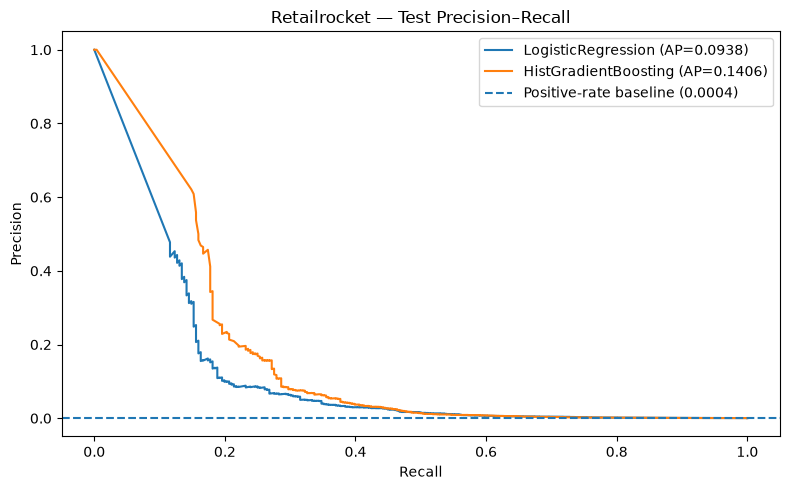

In [12]:

fig_rr_pr = plot_precision_recall(
    y_rr_test,
    {
        "LogisticRegression": rr_test_score_lr,
        "HistGradientBoosting": rr_test_score_hgb,
    },
    "Retailrocket — Test Precision–Recall",
)

plt.show()


In [13]:

rr_metrics = pd.concat(
    [
        rr_validation_metrics,
        rr_test_metrics,
    ],
    ignore_index=True,
)

rr_model_selection = pd.DataFrame([{
    "task": "Retailrocket 7-day transaction",
    "selected_model": rr_selected_name,
    "selection_metric": "validation_pr_auc",
    "selected_threshold": rr_selected_threshold,
    "class_balancing": "balanced weights",
}])

joblib.dump(
    {
        "task": "Retailrocket 7-day transaction",
        "model": rr_selected_model,
        "features": RR_FEATURES,
        "target": RR_TARGET,
        "threshold": rr_selected_threshold,
        "model_name": rr_selected_name,
        "score_name": "transaction_propensity_score",
        "class_balancing": "balanced weights",
    },
    ARTIFACTS_DIR
    / "retailrocket_7d_transaction_model.joblib",
)

print("Retailrocket model artifact saved.")


Retailrocket model artifact saved.



# 3. Online Retail II — 60-day repeat-purchase prediction

Online Retail has a much more balanced target distribution.

Therefore:

- **no class weighting** is used,
- Logistic Regression is standardized through `StandardScaler`,
- HistGradientBoosting is fit directly to the original feature scale.


In [14]:

online = load_split_dataset(
    OR_DIR
)

or_train = online["train"]
or_val = online["validation"]
or_test = online["test"]

or_split_summary = pd.DataFrame({
    "split": [
        "train",
        "validation",
        "test",
    ],
    "rows": [
        len(or_train),
        len(or_val),
        len(or_test),
    ],
    "unique_customers": [
        or_train["CustomerID"].nunique(),
        or_val["CustomerID"].nunique(),
        or_test["CustomerID"].nunique(),
    ],
    "positive_rate_pct": [
        100 * or_train[
            "target_future_purchase"
        ].mean(),
        100 * or_val[
            "target_future_purchase"
        ].mean(),
        100 * or_test[
            "target_future_purchase"
        ].mean(),
    ],
})

display(or_split_summary)


,split,rows,unique_customers,positive_rate_pct
0,train,30629,4496,39.093669
1,validation,5688,3252,41.279887
2,test,5606,3041,50.178380


In [15]:

OR_FEATURES = [
    "orders_180d",
    "revenue_180d",
    "units_180d",
    "unique_products_180d",
    "avg_order_value_180d",
    "recency_days",
    "active_span_days_180d",
    "orders_30d",
    "revenue_30d",
    "units_30d",
    "unique_products_30d",
]

OR_TARGET = "target_future_purchase"

X_or_train = numeric_matrix(
    or_train,
    OR_FEATURES,
)
y_or_train = or_train[
    OR_TARGET
].to_numpy()

X_or_val = numeric_matrix(
    or_val,
    OR_FEATURES,
)
y_or_val = or_val[
    OR_TARGET
].to_numpy()

X_or_test = numeric_matrix(
    or_test,
    OR_FEATURES,
)
y_or_test = or_test[
    OR_TARGET
].to_numpy()

print("Feature count:", len(OR_FEATURES))
print("Training rows:", len(X_or_train))
print("Training positives:", int(y_or_train.sum()))
print(
    "Training positive rate:",
    f"{100 * y_or_train.mean():.4f}%"
)


Feature count: 11
Training rows: 30629
Training positives: 11974
Training positive rate: 39.0937%


In [16]:

or_logistic = make_logistic_model(
    balanced=False,
)

or_histgb = make_histgb_model()

or_logistic.fit(
    X_or_train,
    y_or_train,
)

# No class/sample weighting here:
# Online Retail is not severely imbalanced.
or_histgb.fit(
    X_or_train,
    y_or_train,
)

print("Online Retail models trained without class balancing.")


Online Retail models trained without class balancing.


In [17]:

or_val_score_lr = (
    or_logistic.predict_proba(
        X_or_val
    )[:, 1]
)

or_val_score_hgb = (
    or_histgb.predict_proba(
        X_or_val
    )[:, 1]
)

or_threshold_lr = best_f1_threshold(
    y_or_val,
    or_val_score_lr,
)

or_threshold_hgb = best_f1_threshold(
    y_or_val,
    or_val_score_hgb,
)

or_validation_metrics = pd.DataFrame([
    evaluate_scores(
        y_or_val,
        or_val_score_lr,
        or_threshold_lr,
        "LogisticRegression",
        "validation",
    ),
    evaluate_scores(
        y_or_val,
        or_val_score_hgb,
        or_threshold_hgb,
        "HistGradientBoosting",
        "validation",
    ),
])

display(or_validation_metrics)


,model,split,roc_auc,pr_auc,f1,brier_score,threshold,positive_rate,precision_at_1pct,recall_at_1pct,lift_at_1pct,precision_at_5pct,recall_at_5pct,lift_at_5pct,precision_at_10pct,recall_at_10pct,lift_at_10pct
0,LogisticRegression,validation,0.735216,0.694386,0.643250,0.200829,0.254080,0.412799,0.982456,0.023850,2.379987,0.929825,0.112862,2.252488,0.871705,0.211244,2.111694
1,HistGradientBoosting,validation,0.737835,0.705279,0.637548,0.197416,0.296849,0.412799,1.000000,0.024276,2.422487,0.933333,0.113288,2.260988,0.882250,0.213799,2.137238


In [18]:

or_selected_name = (
    or_validation_metrics
    .sort_values(
        "pr_auc",
        ascending=False,
    )
    .iloc[0]["model"]
)

if or_selected_name == "HistGradientBoosting":
    or_selected_model = or_histgb
    or_selected_threshold = or_threshold_hgb
else:
    or_selected_model = or_logistic
    or_selected_threshold = or_threshold_lr

print(
    "Selected Online Retail model:",
    or_selected_name,
)
print(
    "Validation-selected threshold:",
    round(or_selected_threshold, 6),
)


Selected Online Retail model: HistGradientBoosting
Validation-selected threshold: 0.296849


In [19]:

or_test_score_lr = (
    or_logistic.predict_proba(
        X_or_test
    )[:, 1]
)

or_test_score_hgb = (
    or_histgb.predict_proba(
        X_or_test
    )[:, 1]
)

or_test_metrics = pd.DataFrame([
    evaluate_scores(
        y_or_test,
        or_test_score_lr,
        or_threshold_lr,
        "LogisticRegression",
        "test",
    ),
    evaluate_scores(
        y_or_test,
        or_test_score_hgb,
        or_threshold_hgb,
        "HistGradientBoosting",
        "test",
    ),
])

display(or_test_metrics)


,model,split,roc_auc,pr_auc,f1,brier_score,threshold,positive_rate,precision_at_1pct,recall_at_1pct,lift_at_1pct,precision_at_5pct,recall_at_5pct,lift_at_5pct,precision_at_10pct,recall_at_10pct,lift_at_10pct
0,LogisticRegression,test,0.721244,0.743752,0.682342,0.224755,0.254080,0.501784,1.0,0.020263,1.99289,0.946619,0.094561,1.886508,0.907308,0.180946,1.808166
1,HistGradientBoosting,test,0.725194,0.751951,0.673041,0.220646,0.296849,0.501784,1.0,0.020263,1.99289,0.964413,0.096338,1.921969,0.910873,0.181657,1.815271


In [20]:

if or_selected_name == "HistGradientBoosting":
    or_selected_test_score = or_test_score_hgb
else:
    or_selected_test_score = or_test_score_lr

or_selected_test_pred = (
    or_selected_test_score
    >= or_selected_threshold
).astype(int)

print(
    classification_report(
        y_or_test,
        or_selected_test_pred,
        digits=4,
        zero_division=0,
    )
)

print("Confusion matrix:")
print(
    confusion_matrix(
        y_or_test,
        or_selected_test_pred,
    )
)


              precision    recall  f1-score   support

           0     0.6714    0.6158    0.6424      2793
           1     0.6475    0.7007    0.6730      2813

    accuracy                         0.6584      5606
   macro avg     0.6594    0.6583    0.6577      5606
weighted avg     0.6594    0.6584    0.6578      5606

Confusion matrix:
[[1720 1073]
 [ 842 1971]]


In [21]:

or_scored_test = or_test[
    [
        "CustomerID",
        "prediction_cutoff",
        "label_end",
        OR_TARGET,
        "future_revenue_60d",
    ]
].copy()

or_scored_test[
    "repeat_purchase_probability"
] = or_selected_test_score

or_scored_test = (
    or_scored_test
    .sort_values(
        "repeat_purchase_probability",
        ascending=False,
    )
    .reset_index(drop=True)
)

or_top_customers = (
    or_scored_test
    .head(100)
    .copy()
)

display(
    or_top_customers.head(20)
)


,CustomerID,prediction_cutoff,label_end,target_future_purchase,future_revenue_60d,repeat_purchase_probability
0,15311,2011-08-21 03:36:00,2011-10-20 03:36:00,1,5875.71,0.990618
1,13694,2011-09-20 03:36:00,2011-11-19 03:36:00,1,12758.40,0.990123
2,14606,2011-08-21 03:36:00,2011-10-20 03:36:00,1,1235.96,0.989927
3,14911,2011-09-20 03:36:00,2011-11-19 03:36:00,1,43461.07,0.989356
4,14646,2011-09-20 03:36:00,2011-11-19 03:36:00,1,55189.10,0.988931
5,14156,2011-08-21 03:36:00,2011-10-20 03:36:00,1,24506.11,0.988594
6,14606,2011-09-20 03:36:00,2011-11-19 03:36:00,1,1459.25,0.987798
7,14911,2011-08-21 03:36:00,2011-10-20 03:36:00,1,34494.54,0.987791
8,17450,2011-08-21 03:36:00,2011-10-20 03:36:00,1,75447.20,0.987740
9,17841,2011-09-20 03:36:00,2011-11-19 03:36:00,1,11084.98,0.987556


In [22]:

or_selected_ranking = pd.DataFrame([{
    "population_positive_rate": float(
        y_or_test.mean()
    ),
    "precision_at_1pct": precision_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.01,
    ),
    "recall_at_1pct": recall_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.01,
    ),
    "lift_at_1pct": lift_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.01,
    ),
    "precision_at_5pct": precision_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.05,
    ),
    "recall_at_5pct": recall_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.05,
    ),
    "lift_at_5pct": lift_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.05,
    ),
    "precision_at_10pct": precision_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.10,
    ),
    "recall_at_10pct": recall_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.10,
    ),
    "lift_at_10pct": lift_at_fraction(
        y_or_test,
        or_selected_test_score,
        0.10,
    ),
}])

display(or_selected_ranking)


,population_positive_rate,precision_at_1pct,recall_at_1pct,lift_at_1pct,precision_at_5pct,recall_at_5pct,lift_at_5pct,precision_at_10pct,recall_at_10pct,lift_at_10pct
0,0.501784,1.0,0.020263,1.99289,0.964413,0.096338,1.921969,0.910873,0.181657,1.815271


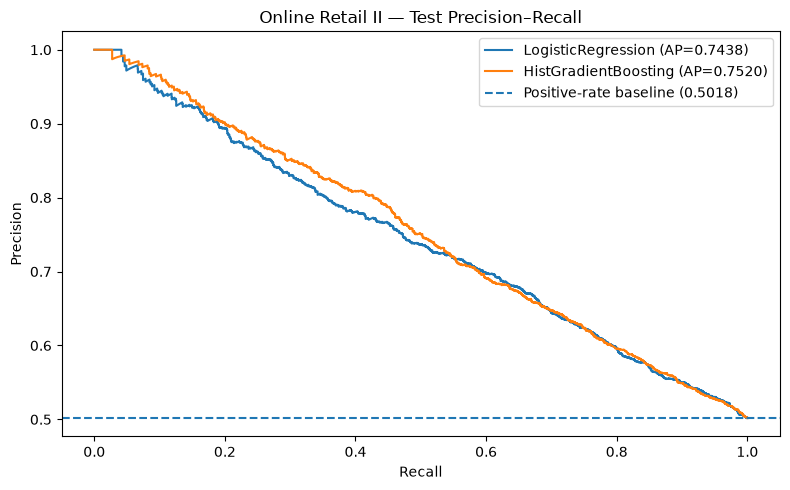

In [23]:

fig_or_pr = plot_precision_recall(
    y_or_test,
    {
        "LogisticRegression": or_test_score_lr,
        "HistGradientBoosting": or_test_score_hgb,
    },
    "Online Retail II — Test Precision–Recall",
)

plt.show()


In [24]:

or_metrics = pd.concat(
    [
        or_validation_metrics,
        or_test_metrics,
    ],
    ignore_index=True,
)

or_model_selection = pd.DataFrame([{
    "task": "Online Retail 60-day repeat purchase",
    "selected_model": or_selected_name,
    "selection_metric": "validation_pr_auc",
    "selected_threshold": or_selected_threshold,
    "class_balancing": "none",
}])

joblib.dump(
    {
        "task": "Online Retail 60-day repeat purchase",
        "model": or_selected_model,
        "features": OR_FEATURES,
        "target": OR_TARGET,
        "threshold": or_selected_threshold,
        "model_name": or_selected_name,
        "score_name": "repeat_purchase_probability",
        "class_balancing": "none",
    },
    ARTIFACTS_DIR
    / "online_retail_60d_repeat_purchase_model.joblib",
)

print("Online Retail model artifact saved.")


Online Retail model artifact saved.



# 4. Final model summary

Because the two datasets have very different positive rates, raw PR-AUC values should **not** be interpreted as directly comparable task difficulty.

Instead, each task should be interpreted relative to its own baseline positive rate and lift.


In [25]:

model_selection = pd.concat(
    [
        rr_model_selection,
        or_model_selection,
    ],
    ignore_index=True,
)

model_comparison = pd.concat(
    [
        rr_metrics.assign(
            task="Retailrocket 7-day transaction"
        ),
        or_metrics.assign(
            task="Online Retail 60-day repeat purchase"
        ),
    ],
    ignore_index=True,
)

display(model_selection)
display(model_comparison)


,task,selected_model,selection_metric,selected_threshold,class_balancing
0,Retailrocket 7-day transaction,HistGradientBoosting,validation_pr_auc,0.980445,balanced weights
1,Online Retail 60-day repeat purchase,HistGradientBoosting,validation_pr_auc,0.296849,none


,model,split,roc_auc,pr_auc,f1,brier_score,threshold,positive_rate,precision_at_1pct,recall_at_1pct,lift_at_1pct,precision_at_5pct,recall_at_5pct,lift_at_5pct,precision_at_10pct,recall_at_10pct,lift_at_10pct,task
0,LogisticRegression,validation,0.865926,0.049681,0.143519,0.110907,1.000000,0.000399,0.014426,0.361290,36.128753,0.004946,0.619355,12.387001,0.002795,0.700000,6.999946,Retailrocket 7-day transaction
1,HistGradientBoosting,validation,0.859549,0.064584,0.169903,0.081976,0.980445,0.000399,0.015971,0.400000,39.999691,0.004869,0.609677,12.193454,0.002679,0.670968,6.709626,Retailrocket 7-day transaction
2,LogisticRegression,test,0.877130,0.093835,0.202667,0.114754,1.000000,0.000433,0.020219,0.467391,46.733563,0.005486,0.634058,12.680841,0.003182,0.735507,7.355003,Retailrocket 7-day transaction
3,HistGradientBoosting,test,0.862218,0.140571,0.241758,0.087254,0.980445,0.000433,0.020376,0.471014,47.095838,0.005580,0.644928,12.898227,0.003104,0.717391,7.173846,Retailrocket 7-day transaction
4,LogisticRegression,validation,0.735216,0.694386,0.643250,0.200829,0.254080,0.412799,0.982456,0.023850,2.379987,0.929825,0.112862,2.252488,0.871705,0.211244,2.111694,Online Retail 60-day repeat purchase
5,HistGradientBoosting,validation,0.737835,0.705279,0.637548,0.197416,0.296849,0.412799,1.000000,0.024276,2.422487,0.933333,0.113288,2.260988,0.882250,0.213799,2.137238,Online Retail 60-day repeat purchase
6,LogisticRegression,test,0.721244,0.743752,0.682342,0.224755,0.254080,0.501784,1.000000,0.020263,1.992890,0.946619,0.094561,1.886508,0.907308,0.180946,1.808166,Online Retail 60-day repeat purchase
7,HistGradientBoosting,test,0.725194,0.751951,0.673041,0.220646,0.296849,0.501784,1.000000,0.020263,1.992890,0.964413,0.096338,1.921969,0.910873,0.181657,1.815271,Online Retail 60-day repeat purchase


In [26]:

selected_ranking_summary = pd.concat(
    [
        rr_selected_ranking.assign(
            task="Retailrocket 7-day transaction"
        ),
        or_selected_ranking.assign(
            task="Online Retail 60-day repeat purchase"
        ),
    ],
    ignore_index=True,
)

display(selected_ranking_summary)


,population_positive_rate,precision_at_1pct,recall_at_1pct,lift_at_1pct,precision_at_5pct,recall_at_5pct,lift_at_5pct,precision_at_10pct,recall_at_10pct,lift_at_10pct,task
0,0.000433,0.020376,0.471014,47.095838,0.005580,0.644928,12.898227,0.003104,0.717391,7.173846,Retailrocket 7-day transaction
1,0.501784,1.000000,0.020263,1.992890,0.964413,0.096338,1.921969,0.910873,0.181657,1.815271,Online Retail 60-day repeat purchase


## 5. Save compact Notebook 08 results

In [27]:

RESULTS_DIR = (
    PROJECT_ROOT
    / "results"
    / "08_behavior_and_customer_prediction"
)

TABLES_DIR = RESULTS_DIR / "tables"
FIGURES_DIR = RESULTS_DIR / "figures"

TABLES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

FIGURES_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

RESULT_TABLES = {
    "retailrocket_split_summary": rr_split_summary,
    "retailrocket_model_metrics": rr_metrics,
    "retailrocket_model_selection": rr_model_selection,
    "retailrocket_selected_ranking": rr_selected_ranking,
    "retailrocket_top_prospects": rr_top_prospects,
    "online_retail_split_summary": or_split_summary,
    "online_retail_model_metrics": or_metrics,
    "online_retail_model_selection": or_model_selection,
    "online_retail_selected_ranking": or_selected_ranking,
    "online_retail_top_customers": or_top_customers,
    "model_selection": model_selection,
    "model_comparison": model_comparison,
    "selected_ranking_summary": selected_ranking_summary,
}

RESULT_FIGURES = {
    "retailrocket_test_precision_recall": fig_rr_pr,
    "online_retail_test_precision_recall": fig_or_pr,
}

for name, table in RESULT_TABLES.items():
    table.to_csv(
        TABLES_DIR / f"{name}.csv",
        index=False,
    )

for name, fig in RESULT_FIGURES.items():
    fig.savefig(
        FIGURES_DIR / f"{name}.png",
        dpi=200,
        bbox_inches="tight",
    )

print("=" * 72)
print("NOTEBOOK 08 COMPLETE")
print("=" * 72)

print("\nResults:")
print(RESULTS_DIR)

print("\nModel artifacts:")
print(
    ARTIFACTS_DIR
    / "retailrocket_7d_transaction_model.joblib"
)
print(
    ARTIFACTS_DIR
    / "online_retail_60d_repeat_purchase_model.joblib"
)


NOTEBOOK 08 COMPLETE

Results:
/Users/noopur/Desktop/resume_projects/ProductPulse/results/08_behavior_and_customer_prediction

Model artifacts:
/Users/noopur/Desktop/resume_projects/ProductPulse/artifacts/models/retailrocket_7d_transaction_model.joblib
/Users/noopur/Desktop/resume_projects/ProductPulse/artifacts/models/online_retail_60d_repeat_purchase_model.joblib
